In [1]:
import re
import gc

from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import warnings
warnings.filterwarnings(action="ignore")

from pymorphy3 import MorphAnalyzer
from stop_words import get_stop_words

from IPython.display import display

import matplotlib as mpl
mpl.rcParams["font.style"] = "oblique"
mpl.rcParams["axes.grid"] = True

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize, Normalizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors

from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics.cluster import pair_confusion_matrix
from scipy.stats import spearmanr

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("./Разметка_текущая (1).csv")
df.head()

,row_id,text,original_label,story_id,message_type,hierarchy_l1,hierarchy_l2,hierarchy_l3,hierarchy_l4,hierarchy_l5,hierarchy,hF1_path,hF1_ancestors,story_size,review_status,review_reason
0,1,"❗️Визит президента Сербии в силе, он летит в М...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
1,2,"Самолет президента Сербии Вучича, направлявший...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
2,3,Власти Литвы запретили перелет в воздушном про...,9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
3,4,"Вучич, прервавший поездку в США из-за недомога...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story;exact_dupli...
4,5,"Вучич, прервавший поездку в США из-за недомога...",vuchich_ill,vucic_health_incident,fact,politics,europe,serbia,leadership_health,NaN,politics/europe/serbia/leadership_health,root/politics/europe/serbia/leadership_health/...,root|root/politics|root/politics/europe|root/p...,4,review,check_boundary_with_adjacent_story;exact_dupli...


In [3]:
df.shape

(863, 16)

In [4]:
MORPH = MorphAnalyzer()
RU_STOPWORDS = set(get_stop_words("russian"))

In [5]:
#del model_embeddings2

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [6]:
model_statistics = make_pipeline(
    TfidfVectorizer(
        lowercase=True,
        max_features=50000,
        ngram_range=(1, 2)
    ),
    TruncatedSVD(
        n_components=300,
        random_state=42
    ),
    Normalizer(copy=False)
)

In [7]:
# todo: run both
model_embeddings1 = SentenceTransformer(
    "jinaai/jina-embeddings-v3", trust_remote_code=True, device="cuda"
)
#model_embeddings2 = SentenceTransformer(
#    "jinaai/jina-embeddings-v5-text-small", trust_remote_code=True, device="cuda"
#)

# gpu issue (FP 16 mode)
#model_embeddings1.half()
#model_embeddings2.half()

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention impl

In [8]:
def make_noise_singletons(y_pred, noise_label=-1):
    y_pred = np.asarray(y_pred).copy()
    noise_mask = y_pred == noise_label

    if not np.any(noise_mask):
        return y_pred

    non_noise = y_pred[~noise_mask]
    next_label = int(np.max(non_noise)) + 1 if non_noise.size else 0

    for offset, idx in enumerate(np.where(noise_mask)[0]):
        y_pred[idx] = next_label + offset

    return y_pred


def pairwise_metrics(y_true, y_pred):
    tn, fp, fn, tp = pair_confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    return precision, recall, f1

In [9]:
def compute_true_paths(df, col="hF1_ancestors", sep="|"):
    return [
        [node for node in str(value).split(sep) if node]
        for value in df[col]
    ]


def strip_root(path, root="root"):
    return [node for node in path if node != root]


def gold_hierarchy_nodes(true_paths, root="root", min_size=2):
    n = len(true_paths)
    groups = defaultdict(list)

    for i, path in enumerate(true_paths):
        for node in strip_root(path, root):
            groups[node].append(i)

    return [
        frozenset(indices)
        for indices in groups.values()
        if min_size <= len(set(indices)) < n
    ]


def linkage_to_hierarchy_nodes(Z, n_samples, min_size=2, include_root=False):
    if Z is None:
        return []

    clusters = {i: frozenset([i]) for i in range(n_samples)}
    nodes = []

    for step, (left, right, _, _) in enumerate(np.asarray(Z)):
        left, right = int(left), int(right)
        leaves = clusters[left] | clusters[right]

        if len(leaves) >= min_size and (include_root or len(leaves) < n_samples):
            nodes.append(leaves)

        clusters[n_samples + step] = leaves

    return nodes


def weighted_best_overlap_f1(source_nodes, target_nodes):
    if not source_nodes or not target_nodes:
        return np.nan

    total_weight = 0
    weighted_sum = 0.0

    for source in source_nodes:
        source_size = len(source)
        best_f1 = 0.0

        for target in target_nodes:
            intersection = len(source & target)
            if intersection == 0:
                continue

            best_f1 = max(
                best_f1,
                2 * intersection / (len(source) + len(target))
            )

        weighted_sum += source_size * best_f1
        total_weight += source_size

    return weighted_sum / total_weight if total_weight else np.nan


def hierarchical_cluster_fscore(tree_linkage, true_paths, root="root", min_size=2):
    n = len(true_paths)
    gold_nodes = gold_hierarchy_nodes(true_paths, root=root, min_size=min_size)
    pred_nodes = linkage_to_hierarchy_nodes(tree_linkage, n, min_size=min_size)

    h_precision = weighted_best_overlap_f1(pred_nodes, gold_nodes)
    h_recall = weighted_best_overlap_f1(gold_nodes, pred_nodes)

    if np.isfinite(h_precision) and np.isfinite(h_recall) and h_precision + h_recall > 0:
        h_f1 = 2 * h_precision * h_recall / (h_precision + h_recall)
    else:
        h_f1 = np.nan

    return h_precision, h_recall, h_f1


def dendrogram_purity(tree_linkage, y_true):
    if tree_linkage is None:
        return np.nan

    y_true = np.asarray(y_true)
    n = len(y_true)

    sizes = {i: 1 for i in range(n)}
    counts = {i: Counter([y_true[i]]) for i in range(n)}

    purity_sum = 0.0
    pair_count = 0

    for step, (left, right, _, _) in enumerate(np.asarray(tree_linkage)):
        left, right = int(left), int(right)

        left_counts = counts[left]
        right_counts = counts[right]
        merged_counts = left_counts + right_counts
        merged_size = sizes[left] + sizes[right]

        for label in left_counts.keys() & right_counts.keys():
            cross_pairs = left_counts[label] * right_counts[label]
            pair_purity = merged_counts[label] / merged_size

            purity_sum += cross_pairs * pair_purity
            pair_count += cross_pairs

        new_cluster_id = n + step
        sizes[new_cluster_id] = merged_size
        counts[new_cluster_id] = merged_counts

    return purity_sum / pair_count if pair_count else np.nan


def common_prefix_len(path_a, path_b, root="root"):
    length = 0

    for node_a, node_b in zip(path_a, path_b):
        if node_a != node_b:
            break
        if node_a != root:
            length += 1

    return length


@lru_cache(maxsize=8)
def _gold_hierarchy_pairwise_arrays_cached(paths, root="root"):
    n = len(paths)
    n_pairs = n * (n - 1) // 2

    lca_similarity = np.empty(n_pairs, dtype=float)
    tree_distance = np.empty(n_pairs, dtype=float)
    path_depths = [len(strip_root(path, root=root)) for path in paths]

    k = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            lca_depth = common_prefix_len(paths[i], paths[j], root=root)

            lca_similarity[k] = lca_depth
            tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca_depth
            k += 1

    return lca_similarity, tree_distance


def gold_hierarchy_pairwise_arrays(true_paths, root="root"):
    return _gold_hierarchy_pairwise_arrays_cached(
        tuple(tuple(path) for path in true_paths),
        root=root,
    )


def condensed_index(n, i, j):
    if i > j:
        i, j = j, i

    return n * i - i * (i + 1) // 2 + j - i - 1


def linkage_cophenetic_distances(Z, n_samples):
    distances = np.empty(n_samples * (n_samples - 1) // 2, dtype=float)
    clusters = {i: [i] for i in range(n_samples)}

    for step, (left, right, distance, _) in enumerate(np.asarray(Z)):
        left, right = int(left), int(right)

        for i in clusters[left]:
            for j in clusters[right]:
                distances[condensed_index(n_samples, i, j)] = distance

        clusters[n_samples + step] = clusters[left] + clusters[right]

    return distances


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 2:
        return np.nan

    x = x[mask]
    y = y[mask]

    if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
        return np.nan

    return spearmanr(x, y).correlation


def hierarchical_tree_metrics(tree_linkage, true_paths, root="root"):
    if tree_linkage is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    n = len(true_paths)
    gold_lca, gold_distance = gold_hierarchy_pairwise_arrays(true_paths, root=root)
    pred_distance = linkage_cophenetic_distances(tree_linkage, n)

    return {
        "lca_similarity_spearman": safe_spearman(gold_lca, -pred_distance),
        "tree_distance_spearman": safe_spearman(gold_distance, pred_distance),
    }


In [10]:
def tfidf_preprocessing(text):
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    result = []

    for token in text.split():
        if len(token) < 2: continue
        lemma = MORPH.parse(token)[0].normal_form
        if lemma in RU_STOPWORDS: continue

        result.append(lemma)

    return " ".join(result)

In [11]:
def clustering_metrics(X, y_true, y_pred, true_paths=None, tree_linkage=None):
    y_pred_external = make_noise_singletons(y_pred)
    precision, recall, f1 = pairwise_metrics(y_true, y_pred_external)
    ari = adjusted_rand_score(y_true, y_pred_external)

    if true_paths is not None:
        h_precision, h_recall, h_f1 = hierarchical_cluster_fscore(
            tree_linkage=tree_linkage,
            true_paths=true_paths,
        )
        tree_metrics = hierarchical_tree_metrics(tree_linkage, true_paths)
        purity = dendrogram_purity(tree_linkage, y_true)
    else:
        h_precision, h_recall, h_f1 = np.nan, np.nan, np.nan
        tree_metrics = {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }
        purity = np.nan

    mask = y_pred != -1
    internal = {
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    if len(set(y_pred[mask])) >= 2:
        internal["silhouette"] = silhouette_score(X[mask], y_pred[mask])
        internal["calinski_harabasz"] = calinski_harabasz_score(X[mask], y_pred[mask])
        internal["davies_bouldin"] = davies_bouldin_score(X[mask], y_pred[mask])

    return {
        "precision": precision,
        "recall": recall,
        "f1-score": f1,
        "h_precision": h_precision,
        "h_recall": h_recall,
        "h_f1-score": h_f1,
        "lca_similarity_spearman": tree_metrics["lca_similarity_spearman"],
        "tree_distance_spearman": tree_metrics["tree_distance_spearman"],
        "dendrogram_purity": purity,
        "ari": ari,
        **internal
    }


In [12]:
def twonn_dimension(X, metric="euclidean", eps=1e-12):
    X = np.asarray(X)

    if len(X) < 3:
        return np.nan

    nn = NearestNeighbors(n_neighbors=3, metric=metric)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    r1 = distances[:, 1]
    r2 = distances[:, 2]
    mask = np.isfinite(r1) & np.isfinite(r2) & (r1 > eps) & (r2 > eps)

    if mask.sum() < 3:
        return np.nan

    log_mu = np.log(r2[mask] / r1[mask])
    mean_log_mu = np.mean(log_mu)

    return 1 / mean_log_mu if mean_log_mu > eps else np.nan


def reduce_embeddings(X, pca_dim=100, umap_dim=15, return_twonn=False):
    twonn_raw = twonn_dimension(X)

    X_norm = normalize(X)
    pca_dim = min(pca_dim, X_norm.shape[1], X_norm.shape[0] - 1)
    X_pca = PCA(
        n_components=pca_dim,
        random_state=42
    ).fit_transform(X_norm)
    twonn_pca = twonn_dimension(X_pca)

    X_umap = UMAP(
        n_components=umap_dim,
        metric="cosine",
        random_state=42
    ).fit_transform(X_pca)
    twonn_umap = twonn_dimension(X_umap)

    if return_twonn:
        return X_umap, {
            "twonn_raw": twonn_raw,
            "twonn_pca": twonn_pca,
            "twonn_umap": twonn_umap,
        }

    return X_umap


In [13]:
def run_clusterers(X, min_cluster_size=5):
    hdbscan = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean"
    ).fit(X)

    return {
        "hdbscan": {
            "labels": hdbscan.labels_,
            "tree_linkage": hdbscan.single_linkage_tree_.to_numpy(),
        },
    }


In [14]:
#for tf-idf
df["text_processed"] = df["text"].apply(tfidf_preprocessing)

In [15]:
texts = df["text"].astype(str).tolist()
preproc_texts = df["text_processed"].tolist()
y_true = df["original_label"].astype(str).to_numpy()
true_paths = compute_true_paths(df)

embeddings_dict = {}
embeddings_dict["tfidf_svd"] = model_statistics.fit_transform(preproc_texts)
#embeddings_dict["jina_embeddings_v3"] = model_embeddings1.encode(
#    texts,
#    task="separation",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)
#embeddings_dict["jina_embeddings_v5-text-small"] = model_embeddings2.encode(
#    texts,
#    task="text-matching",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)


In [16]:
embeddings_dict["jina_embeddings_v5_text_small_matching"] = np.load("./embeddings/embeddings_v5_text_small.npy")
embeddings_dict["jina_embeddings_v3"] = np.load("./embeddings/embeddings_v3_separation.npy")

In [17]:
def full_pipeline(embeddings_dict, min_cluster_sizes=[5, 10, 15, 20]):
    reduced_embeddings = {}

    for emb_name, X_raw in embeddings_dict.items():
        print(f"Reducing embeddings: {emb_name}")
        X_reduced, twonn_metrics = reduce_embeddings(
            X_raw,
            pca_dim=100,
            umap_dim=15,
            return_twonn=True,
        )
        reduced_embeddings[emb_name] = {
            "X": X_reduced,
            "twonn": twonn_metrics,
        }

    results_total = {}
    for idx, min_cluster_size in enumerate(min_cluster_sizes):
        results_clustering = []
        print(f"{idx+1} out of {len(min_cluster_sizes)}")

        for emb_name, reduced_data in reduced_embeddings.items():
            X_reduced = reduced_data["X"]
            twonn_metrics = reduced_data["twonn"]
        
            clusterers_output = run_clusterers(
                X_reduced,
                min_cluster_size=min_cluster_size
            )
        
            for algo_name, clusterer_output in clusterers_output.items():
                y_pred = clusterer_output["labels"]
                tree_linkage = clusterer_output["tree_linkage"]
                metrics = clustering_metrics(
                    X=X_reduced,
                    y_true=y_true,
                    y_pred=y_pred,
                    true_paths=true_paths,
                    tree_linkage=tree_linkage,
                )
        
                results_clustering.append({
                    "embeddings": emb_name,
                    "algorithm": algo_name,
                    **metrics,
                    **twonn_metrics,
                    "n_pred_clusters": len(set(y_pred)) - int(-1 in y_pred),
                    "n_noise": int(np.sum(y_pred == -1))
                })
        
        results_df = pd.DataFrame(results_clustering)
        results_df = results_df[
            [
                "algorithm",
                "embeddings",
                "precision",
                "recall",
                "f1-score",
                "h_precision",
                "h_recall",
                "h_f1-score",
                "lca_similarity_spearman",
                "tree_distance_spearman",
                "dendrogram_purity",
                "ari",
                "silhouette",
                "calinski_harabasz",
                "davies_bouldin",
                "twonn_raw",
                "twonn_pca",
                "twonn_umap",
                "n_pred_clusters",
                "n_noise",
            ]
        ]
        results_total[f"res_{min_cluster_size}"] = results_df
    
    return results_total


In [18]:
results_dfs = full_pipeline(
    embeddings_dict,
    min_cluster_sizes=np.arange(2, 30, 1)
)


Reducing embeddings: tfidf_svd
Reducing embeddings: jina_embeddings_v5_text_small_matching
Reducing embeddings: jina_embeddings_v3
1 out of 28
2 out of 28
3 out of 28
4 out of 28
5 out of 28
6 out of 28
7 out of 28
8 out of 28
9 out of 28
10 out of 28
11 out of 28
12 out of 28
13 out of 28
14 out of 28
15 out of 28
16 out of 28
17 out of 28
18 out of 28
19 out of 28
20 out of 28
21 out of 28
22 out of 28
23 out of 28
24 out of 28
25 out of 28
26 out of 28
27 out of 28
28 out of 28


In [19]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    display(df)

res_2


,algorithm,embeddings,precision,recall,f1-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd,0.797386,0.441807,0.568580,0.602296,0.795675,0.685611,0.248750,0.237424,0.814686,0.560199,0.705152,2899.034976,0.426640,5.884047,4.828226,2.934265,88,85
1,hdbscan,jina_embeddings_v5_text_small_matching,0.904769,0.620260,0.735975,0.638781,0.814563,0.716042,0.317977,0.308545,0.866001,0.730108,0.712962,8055.573758,0.467340,12.321333,7.112123,2.868447,74,60
2,hdbscan,jina_embeddings_v3,0.851304,0.689367,0.761825,0.676260,0.833554,0.746714,0.419098,0.410279,0.891013,0.755989,0.753406,11628.232687,0.398424,9.319099,6.231448,2.950025,73,56


res_3


,algorithm,embeddings,precision,recall,f1-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd,0.798738,0.534956,0.640761,0.618964,0.796523,0.696607,0.251528,0.239999,0.821345,0.632890,0.718454,3052.032442,0.388768,5.884047,4.828226,2.934265,66,88
1,hdbscan,jina_embeddings_v5_text_small_matching,0.870294,0.741776,0.800912,0.650091,0.806368,0.719845,0.309037,0.299886,0.858515,0.795892,0.748195,7375.597301,0.399667,12.321333,7.112123,2.868447,56,53
2,hdbscan,jina_embeddings_v3,0.837678,0.769339,0.802055,0.674902,0.824959,0.742424,0.400317,0.392624,0.886001,0.796857,0.766494,13174.842783,0.355146,9.319099,6.231448,2.950025,55,32


res_4


,algorithm,embeddings,precision,recall,f1-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd,0.784065,0.683030,0.730068,0.607374,0.788450,0.686167,0.251890,0.240449,0.820672,0.723179,0.741967,2809.075957,0.351222,5.884047,4.828226,2.934265,52,73
1,hdbscan,jina_embeddings_v5_text_small_matching,0.823817,0.846193,0.834855,0.652456,0.792705,0.715775,0.319039,0.309797,0.848179,0.830258,0.733423,7089.919303,0.362805,12.321333,7.112123,2.868447,44,38
2,hdbscan,jina_embeddings_v3,0.820551,0.775978,0.797642,0.685622,0.813366,0.744051,0.399083,0.391398,0.878556,0.792245,0.780724,14114.625699,0.323246,9.319099,6.231448,2.950025,47,54


res_5


,algorithm,embeddings,precision,recall,f1-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd,0.756635,0.691178,0.722427,0.610301,0.775595,0.683091,0.251699,0.240273,0.816839,0.715158,0.739243,2751.633949,0.348177,5.884047,4.828226,2.934265,45,88
1,hdbscan,jina_embeddings_v5_text_small_matching,0.544510,0.890957,0.675926,0.660461,0.778270,0.714542,0.318868,0.309677,0.841373,0.664806,0.721655,2788.024010,0.333444,12.321333,7.112123,2.868447,36,34
2,hdbscan,jina_embeddings_v3,0.743543,0.854240,0.795057,0.692920,0.810178,0.746975,0.409244,0.401967,0.880082,0.789027,0.784733,12186.213392,0.300970,9.319099,6.231448,2.950025,40,29


res_6


,algorithm,embeddings,precision,recall,f1-score,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd,0.746545,0.749925,0.748231,0.614284,0.773665,0.684824,0.255453,0.243912,0.814872,0.741301,0.740960,2557.551108,0.375733,5.884047,4.828226,2.934265,39,79
1,hdbscan,jina_embeddings_v5_text_small_matching,0.535404,0.891460,0.669007,0.660921,0.769915,0.711267,0.310677,0.301619,0.838921,0.657571,0.737076,2835.301090,0.309097,12.321333,7.112123,2.868447,34,39
2,hdbscan,jina_embeddings_v3,0.753546,0.881803,0.812645,0.698729,0.805203,0.748197,0.408924,0.401697,0.869954,0.807085,0.801730,12648.459869,0.281731,9.319099,6.231448,2.950025,38,36


In [20]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    print(df[df["algorithm"] == "hdbscan"])

res_2
  algorithm                              embeddings  precision    recall  \
0   hdbscan                               tfidf_svd   0.797386  0.441807   
1   hdbscan  jina_embeddings_v5_text_small_matching   0.904769  0.620260   
2   hdbscan                      jina_embeddings_v3   0.851304  0.689367   

   f1-score  h_precision  h_recall  h_f1-score  lca_similarity_spearman  \
0  0.568580     0.602296  0.795675    0.685611                 0.248750   
1  0.735975     0.638781  0.814563    0.716042                 0.317977   
2  0.761825     0.676260  0.833554    0.746714                 0.419098   

   tree_distance_spearman  dendrogram_purity       ari  silhouette  \
0                0.237424           0.814686  0.560199    0.705152   
1                0.308545           0.866001  0.730108    0.712962   
2                0.410279           0.891013  0.755989    0.753406   

   calinski_harabasz  davies_bouldin  twonn_raw  twonn_pca  twonn_umap  \
0        2899.034976        0.426

In [21]:
all_results = []

for key, df in results_dfs.items():
    min_cluster_size = int(key.replace("res_", ""))
    tmp = df.copy()
    tmp["min_cluster_size"] = min_cluster_size

    all_results.append(tmp)

total_df = pd.concat(all_results, ignore_index=True)

In [22]:
external_metrics = [
    "precision",
    "recall",
    "f1-score",
    "ari",
    "h_precision",
    "h_recall",
    "h_f1-score",
    "lca_similarity_spearman",
    "tree_distance_spearman",
    "dendrogram_purity",
]

internal_metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
]

total_df["davies_bouldin_inv"] = -total_df["davies_bouldin"]

internal_metrics_for_corr = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin_inv",
]

hdbscan_df = total_df[total_df["algorithm"] == "hdbscan"].copy()

def spearman_corr_with_pvalues(df, x_metrics, y_metrics):
    corr = pd.DataFrame(index=x_metrics, columns=y_metrics, dtype=float)
    pval = pd.DataFrame(index=x_metrics, columns=y_metrics, dtype=float)
    n_obs = pd.DataFrame(index=x_metrics, columns=y_metrics, dtype=int)

    for x in x_metrics:
        for y in y_metrics:
            tmp = df[[x, y]].dropna()
            n_obs.loc[x, y] = len(tmp)

            if len(tmp) < 3 or tmp[x].nunique() < 2 or tmp[y].nunique() < 2:
                corr.loc[x, y] = np.nan
                pval.loc[x, y] = np.nan
                continue

            r, p = spearmanr(tmp[x], tmp[y])
            corr.loc[x, y] = r
            pval.loc[x, y] = p

    return corr, pval


corr_internal_external, pval_internal_external = spearman_corr_with_pvalues(
    hdbscan_df,
    internal_metrics_for_corr,
    external_metrics,
)

print("Spearman correlation: internal metrics vs external metrics")
display(corr_internal_external)

print("p-values")
display(pval_internal_external.round(4))

Spearman correlation: internal metrics vs external metrics


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.390517,0.265174,0.486701,0.483380,0.513499,0.236966,0.367401,0.521365,0.527926,0.325374
calinski_harabasz,0.566828,0.153176,0.620650,0.620934,0.818775,0.618339,0.769914,0.835086,0.831279,0.689879
davies_bouldin_inv,0.273132,0.545748,0.455173,0.448612,0.738264,0.357489,0.556629,0.678641,0.687024,0.472626


p-values


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.0002,0.0148,0.0,0.0,0.0,0.0300,0.0006,0.0,0.0,0.0025
calinski_harabasz,0.0000,0.1642,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0000
davies_bouldin_inv,0.0119,0.0000,0.0,0.0,0.0,0.0008,0.0000,0.0,0.0,0.0000


In [23]:
def corr_table_to_long(corr, pval, x_name="x_metric", y_name="y_metric"):
    corr_long = (
        corr
        .stack()
        .rename("spearman_corr")
        .reset_index()
        .rename(columns={"level_0": x_name, "level_1": y_name})
    )

    pval_long = (
        pval
        .stack()
        .rename("p_value")
        .reset_index()
        .rename(columns={"level_0": x_name, "level_1": y_name})
    )

    return (
        corr_long
        .merge(pval_long, on=[x_name, y_name], how="left")
        .sort_values("spearman_corr", ascending=False)
    )


corr_internal_external_long = corr_table_to_long(
    corr_internal_external,
    pval_internal_external,
    x_name="internal_metric",
    y_name="external_metric",
)

corr_internal_external_long.to_csv(RESULTS_DIR / "correlations_internal_external.csv", index=False)
display(corr_internal_external_long.round(4))


,internal_metric,external_metric,spearman_corr,p_value
17,calinski_harabasz,lca_similarity_spearman,0.8351,0.0000
18,calinski_harabasz,tree_distance_spearman,0.8313,0.0000
14,calinski_harabasz,h_precision,0.8188,0.0000
16,calinski_harabasz,h_f1-score,0.7699,0.0000
24,davies_bouldin_inv,h_precision,0.7383,0.0000
19,calinski_harabasz,dendrogram_purity,0.6899,0.0000
28,davies_bouldin_inv,tree_distance_spearman,0.6870,0.0000
27,davies_bouldin_inv,lca_similarity_spearman,0.6786,0.0000
13,calinski_harabasz,ari,0.6209,0.0000
12,calinski_harabasz,f1-score,0.6207,0.0000


In [28]:
twonn_metrics = [
    "twonn_raw",
    "twonn_pca",
    "twonn_umap",
]

print("Unique TwoNN values")
display(hdbscan_df.groupby("embeddings")[twonn_metrics].first().round(4))

corr_twonn_external, pval_twonn_external = spearman_corr_with_pvalues(
    hdbscan_df,
    twonn_metrics,
    external_metrics,
)

corr_twonn_internal, pval_twonn_internal = spearman_corr_with_pvalues(
    hdbscan_df,
    twonn_metrics,
    internal_metrics_for_corr,
)

print("Correlation: TwoNN vs external metrics")
display(corr_twonn_external.round(3))

print("Correlation: TwoNN vs internal metrics")
display(corr_twonn_internal.round(3))

corr_twonn_external_long = corr_table_to_long(
    corr_twonn_external,
    pval_twonn_external,
    x_name="twonn_metric",
    y_name="external_metric",
)

corr_twonn_internal_long = corr_table_to_long(
    corr_twonn_internal,
    pval_twonn_internal,
    x_name="twonn_metric",
    y_name="internal_metric",
)

corr_twonn_external_long.to_csv(RESULTS_DIR / "correlations_twonn_external.csv", index=False)
corr_twonn_internal_long.to_csv(RESULTS_DIR / "correlations_twonn_internal.csv", index=False)

print("TwoNN vs external metrics, long format")
display(corr_twonn_external_long.round(4))

print("TwoNN vs internal metrics, long format")
display(corr_twonn_internal_long.round(4))


Unique TwoNN values


,twonn_raw,twonn_pca,twonn_umap
embeddings,,,
jina_embeddings_v3,9.3191,6.2314,2.9500
jina_embeddings_v5_text_small_matching,12.3213,7.1121,2.8684
tfidf_svd,5.8840,4.8282,2.9343


Correlation: TwoNN vs external metrics


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
twonn_raw,-0.006,0.487,0.104,0.098,0.503,0.117,0.324,0.471,0.471,0.232
twonn_pca,-0.006,0.487,0.104,0.098,0.503,0.117,0.324,0.471,0.471,0.232
twonn_umap,0.054,-0.023,0.093,0.093,0.328,0.097,0.191,0.471,0.471,0.122


Correlation: TwoNN vs internal metrics


,silhouette,calinski_harabasz,davies_bouldin_inv
twonn_raw,0.379,0.283,0.486
twonn_pca,0.379,0.283,0.486
twonn_umap,0.159,0.497,0.147


TwoNN vs external metrics, long format


,twonn_metric,external_metric,spearman_corr,p_value
4,twonn_raw,h_precision,0.5027,0.0000
14,twonn_pca,h_precision,0.5027,0.0000
11,twonn_pca,recall,0.4871,0.0000
1,twonn_raw,recall,0.4871,0.0000
8,twonn_raw,tree_distance_spearman,0.4714,0.0000
7,twonn_raw,lca_similarity_spearman,0.4714,0.0000
28,twonn_umap,tree_distance_spearman,0.4714,0.0000
18,twonn_pca,tree_distance_spearman,0.4714,0.0000
17,twonn_pca,lca_similarity_spearman,0.4714,0.0000
27,twonn_umap,lca_similarity_spearman,0.4714,0.0000


TwoNN vs internal metrics, long format


,twonn_metric,internal_metric,spearman_corr,p_value
7,twonn_umap,calinski_harabasz,0.4973,0.0000
5,twonn_pca,davies_bouldin_inv,0.4859,0.0000
2,twonn_raw,davies_bouldin_inv,0.4859,0.0000
0,twonn_raw,silhouette,0.3794,0.0004
3,twonn_pca,silhouette,0.3794,0.0004
4,twonn_pca,calinski_harabasz,0.2826,0.0092
1,twonn_raw,calinski_harabasz,0.2826,0.0092
6,twonn_umap,silhouette,0.1594,0.1477
8,twonn_umap,davies_bouldin_inv,0.1467,0.1829


In [25]:
total_df.to_csv(RESULTS_DIR / "results_clustering.csv")
#total_df = pd.read_csv(RESULTS_DIR / "results_clustering.csv") 

In [26]:
def plot_hdbscan_results(savename=None):
    cols_to_plot = [
        "precision", "recall", "f1-score", "h_f1-score",
        "lca_similarity_spearman", "tree_distance_spearman", "dendrogram_purity", "ari",
        "silhouette", "calinski_harabasz", "davies_bouldin"
    ]

    plot_data = total_df[total_df["algorithm"] == "hdbscan"].copy()

    embeddings = plot_data["embeddings"].unique()
    colors = dict(zip(embeddings, plt.get_cmap("tab10").colors))

    n_cols = 4
    n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4.5 * n_rows))
    axes = axes.flatten()

    for metric, ax in zip(cols_to_plot, axes):
        for emb_name in embeddings:
            filtered_data = plot_data[plot_data["embeddings"] == emb_name].sort_values("min_cluster_size")

            ax.plot(
                filtered_data["min_cluster_size"],
                filtered_data[metric],
                marker="o",
                linewidth=2,
                markersize=4,
                color=colors[emb_name],
                label=emb_name
            )

            if metric == "davies_bouldin": best_idx = filtered_data[metric].idxmin()
            else: best_idx = filtered_data[metric].idxmax()

            best_row = filtered_data.loc[best_idx]
            best_mcs = best_row["min_cluster_size"]
            best_value = best_row[metric]

            ax.axvline(best_mcs, color=colors[emb_name], linestyle="--", alpha=0.25)

            ax.text(
                best_mcs,
                best_value,
                f"{int(best_mcs)}",
                fontsize=8,
                ha="center",
                va="bottom",
                color=colors[emb_name]
            )

        ax.set_title(metric)
        ax.set_xlabel("min_cluster_size")
        ax.grid(alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[len(cols_to_plot):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    fig.legend(by_label.values(), by_label.keys(), loc="lower center", ncols=len(by_label), frameon=False)

    fig.suptitle("HDBSCAN results by min_cluster_size", fontsize=16)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

    if savename is not None:
        fig.savefig(RESULTS_DIR / f"{savename}.jpg")


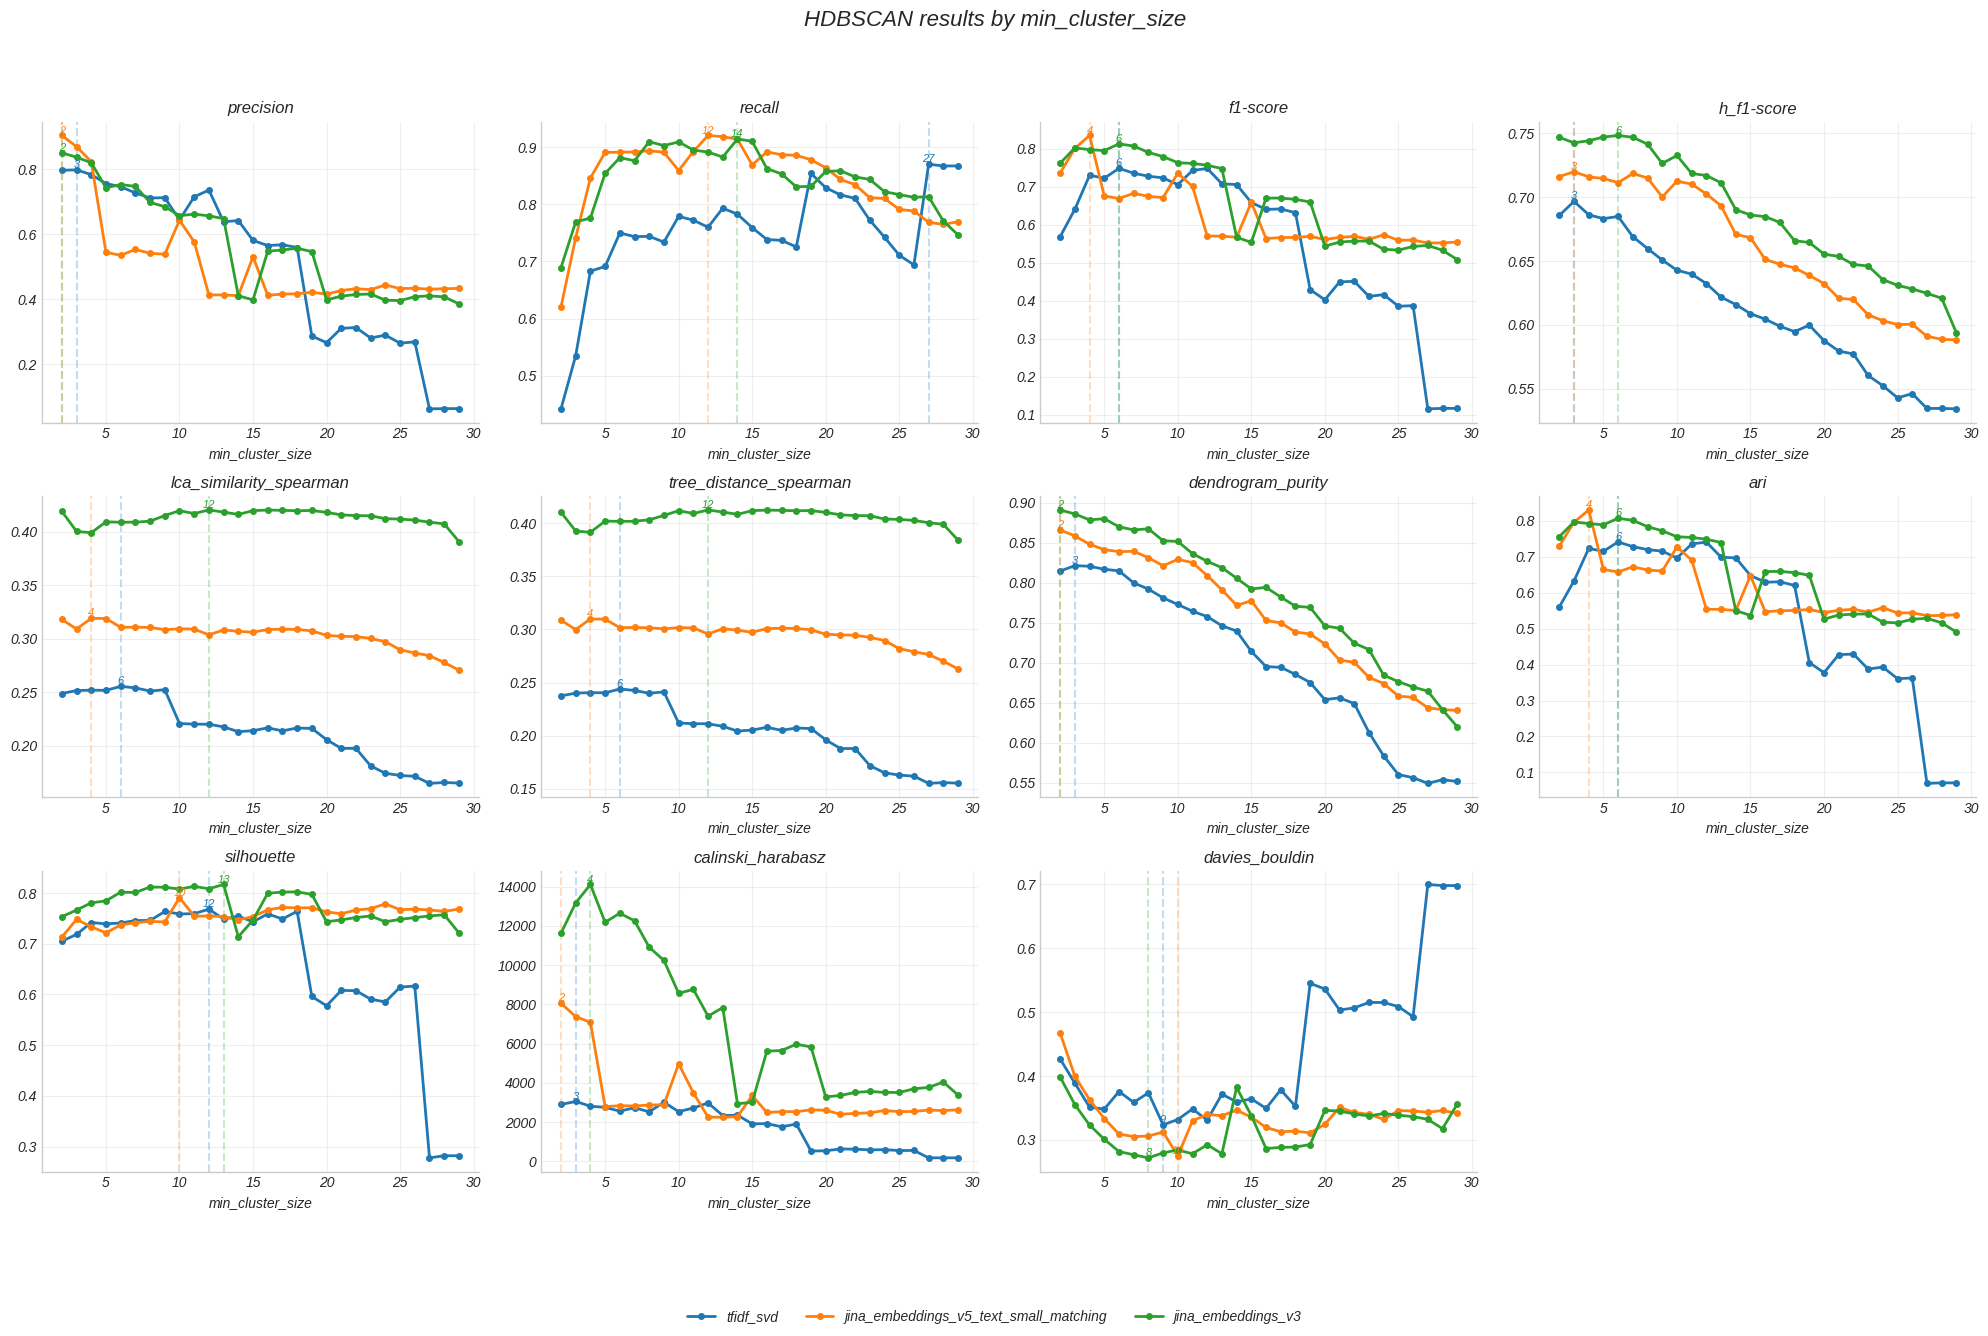

In [27]:
plot_hdbscan_results("results_hdbscan")